In [1]:
# Email Signature Extraction and BERT NER Fine-Tuning Notebook

# 🛠️ Setup and Imports
import os
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizerFast, BertForTokenClassification, Trainer, TrainingArguments
from transformers import DataCollatorForTokenClassification
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  

In [2]:
# 📥 Load Email Data
df = pd.read_csv("data/enron_emails.csv")  # Must contain 'email_id' and 'body'

In [3]:
df.columns

Index(['file', 'message'], dtype='object')

In [4]:
df.head()  # Display the first few rows of the DataFrame

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [5]:
df.info

<bound method DataFrame.info of                              file  \
0           allen-p/_sent_mail/1.   
1          allen-p/_sent_mail/10.   
2         allen-p/_sent_mail/100.   
3        allen-p/_sent_mail/1000.   
4        allen-p/_sent_mail/1001.   
...                           ...   
517396  zufferli-j/sent_items/95.   
517397  zufferli-j/sent_items/96.   
517398  zufferli-j/sent_items/97.   
517399  zufferli-j/sent_items/98.   
517400  zufferli-j/sent_items/99.   

                                                  message  
0       Message-ID: <18782981.1075855378110.JavaMail.e...  
1       Message-ID: <15464986.1075855378456.JavaMail.e...  
2       Message-ID: <24216240.1075855687451.JavaMail.e...  
3       Message-ID: <13505866.1075863688222.JavaMail.e...  
4       Message-ID: <30922949.1075863688243.JavaMail.e...  
...                                                   ...  
517396  Message-ID: <26807948.1075842029936.JavaMail.e...  
517397  Message-ID: <25835861.1075842029959

In [6]:
df['email_id'] = df['file'].str.rstrip('.').str.extract(r'(\d+)$').astype(int)

In [7]:
df.drop(columns=['file'], inplace=True)

In [8]:
print(df['message'][0])  # Check the email_id extraction

Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin: Allen-P
X-FileName: pallen (Non-Privileged).pst

Here is our forecast

 


In [9]:
def multiline_regex_sub(text, pattern_replacements):
    """Applies multiple regex substitutions to a multiline string.

    Args:
        text: The input multiline string.
        pattern_replacements: A list of tuples, where each tuple contains a regex pattern and its replacement string.

    Returns:
        The modified string with all replacements applied.
    """
    for pattern, replacement in pattern_replacements:
        text = re.sub(pattern, replacement, text, flags=re.MULTILINE | re.DOTALL)
    return text

# Sample DataFrame
data = {'text_column': ["Line 1\nLine 2 with pattern1\nLine 3", 
                        "Another text\nwith pattern2 and pattern3\nEnd of text",
                        "Just one line"]}
df_2 = pd.DataFrame(data)

# Define patterns and replacements
pattern_replacements = [
    (r"pattern1", "REPLACEMENT1"),
    (r"pattern2", "REPLACEMENT2"),
    (r"pattern3", "REPLACEMENT3")
]

# Apply the function to the DataFrame column
df_2['modified_text_column'] = df_2['text_column'].apply(lambda x: multiline_regex_sub(x, pattern_replacements))

print(df_2)

                                         text_column  \
0               Line 1\nLine 2 with pattern1\nLine 3   
1  Another text\nwith pattern2 and pattern3\nEnd ...   
2                                      Just one line   

                                modified_text_column  
0           Line 1\nLine 2 with REPLACEMENT1\nLine 3  
1  Another text\nwith REPLACEMENT2 and REPLACEMEN...  
2                                      Just one line  


In [10]:
# Define the pattern to match the lines to be removed
regex_patterns  = [
    r'^Message-ID:.*$\n',
r'^Date:.*$\n',
r'^From:.*$\n',
r'^To:.*$\n',
r'^Subject:.*$\n',
r'^Mime-Version:.*$\n',
r'^Content-Type:.*$\n',
r'^Content-Transfer-Encoding:.*$\n',
r'^X-From:.*$\n',
r'^X-To:.*$\n',
r'^X-cc:.*$\n',
r'^X-bcc:.*$\n',
r'^X-Folder:.*$\n',
r'^X-Origin:.*$\n',
r'^X-FileName:.*$\n'
]

def replace_multiple_patterns(df, source_column, dest_column, patterns):
    """
    Applies multiple regex substitutions with an empty string in a DataFrame column,
    handling multiline strings.

    Args:
        df (pd.DataFrame): The DataFrame.
        column (str): The column name.
        patterns (list of str): A list of regex patterns to replace.

    Returns:
         pd.DataFrame: The modified DataFrame.
    """
    df[dest_column] = df[source_column].astype(str).apply(lambda text: re.sub('|'.join(patterns), '', text, flags=re.MULTILINE) if pd.notna(text) else text)
    return df


df = replace_multiple_patterns(df.copy(), 'message', 'body', regex_patterns)

# Display the first few rows of the DataFrame after cleaning
df.head()


,message,email_id,body
0,Message-ID: <18782981.1075855378110.JavaMail.e...,1,\nHere is our forecast\n\n
1,Message-ID: <15464986.1075855378456.JavaMail.e...,10,\nTraveling to have a business meeting takes t...
2,Message-ID: <24216240.1075855687451.JavaMail.e...,100,\ntest successful. way to go!!!
3,Message-ID: <13505866.1075863688222.JavaMail.e...,1000,"\nRandy,\n\n Can you send me a schedule of the..."
4,Message-ID: <30922949.1075863688243.JavaMail.e...,1001,\nLet's shoot for Tuesday at 11:45.


In [11]:
# Extract the first 100000 rows and select the required columns
subset = df.loc[:100000, ['email_id', 'body']]

# Save the subset to a JSON file
subset.to_json("enron_email_data.json", orient="records", lines=True)

In [12]:
# ✂️ Extract Signature from Email Text
def extract_signature(text):
    signature_markers = [
        #r"(?i)(\n--\n|\nbest regards,|\nthanks,|\nthank you,|\nregards,|\nsincerely,|\ncheers,|\nrespectfully,)"
        #r"(?i)(\nbest regards,|\nthanks,|\nthank you,|\nregards,|\nsincerely,|\ncheers,|\nrespectfully,)"
        r"(?i)(best regards,|thanks,|thank you,|regards,|sincerely,|cheers,|respectfully,)"
    ]
    #print(f"Original text: {text}")  # Debugging line to check the original text
    for pattern in signature_markers:
        match = re.search(pattern, text)
        
        if match:
            start_position = match.start()
            end_position = match.end()
            span = match.span()

            print(f"Match found: {match.group()}")
            print(f"Start position: {start_position}")
            print(f"End position: {end_position}")
            print(f"Span: {span}")
            print(f"Signature Text: {text[start_position:]}")
        else:
            print("Match not found.")
        
        #parts = re.split(marker, text)
        #print(parts)  # Debugging line to check the split parts
        #if len(parts) > 1:
        #    return parts[-1].strip()
    return ""

test_str = "\n---------------------- Forwarded by Phillip K Allen\/HOU\/ECT on 10\/03\/2000 \n04:30 PM ---------------------------\n\n\n\"George Richards\" <cbpres@austin.rr.com> on 10\/03\/2000 06:35:56 AM\nPlease respond to <cbpres@austin.rr.com>\ncc: \"Larry Lewter\" <retwell@mail.sanmarcos.net> \n\n\nWestgate\n\nEnclosed are demographics on the Westgate site from Investor's Alliance.\nInvestor's Alliance says that these demographics are similar to the package\non San Marcos that you received earlier.\nIf there are any other questions or information requirements, let me know.\nThen, let me know your interest level in the Westgate project?\n\nSan Marcos\nThe property across the street from the Sagewood units in San Marcos is for\nsale and approved for 134 units.  The land is selling for $2.50 per square\nfoot as it is one of only two remaining approved multifamily parcels in West\nSan Marcos, which now has a moratorium on development.\n\nSeveral new studies we have looked at show that the rents for our duplexes\nand for these new units are going to be significantly higher, roughly $1.25\nper square foot if leased for the entire unit on a 12-month lease and\n$1.30-$1.40 psf if leased on a 12-month term, but by individual room.  This\nproperty will have the best location for student housing of all new\nprojects, just as the duplexes do now.\n\nIf this project is of serious interest to you, please let me know as there\nis a very, very short window of opportunity.  The equity requirement is not\nyet known, but it would be likely to be $300,000 to secure the land.  I will\nknow more on this question later today.\n\nSincerely,\n\nGeorge W. Richards\nPresident, Creekside Builders, LLC\n\n\n - winmail.dat\n"

print(extract_signature(test_str))  # Check the signature extraction
print(extract_signature("Best regards,\nJohn Doe\n"))  # Check the signature extraction with a simple case

Match found: Sincerely,
Start position: 1588
End position: 1598
Span: (1588, 1598)
Signature Text: Sincerely,

George W. Richards
President, Creekside Builders, LLC


 - winmail.dat


Match found: Best regards,
Start position: 0
End position: 13
Span: (0, 13)
Signature Text: Best regards,
John Doe




In [13]:
def extract_signature_non(text):
    signature_markers = [
        r"(?i)(\n--\n|\nbest regards,|\nthanks,|\nthank you,|\nregards,|\nsincerely,|\ncheers,|\nrespectfully,)"
    ]
    for marker in signature_markers:
        parts = re.split(marker, text)
        if len(parts) > 1:
            return parts[-1].strip()
    return ""

In [14]:
# ✂️ Extract Signature from Email Text
def extract_signature(text):
    signature_markers = [
        r"(?i)(best regards,|thanks,|thank you,|regards,|sincerely,|cheers,|respectfully,)"
    ]
    #print(f"Original text: {text}")  # Debugging line to check the original text
    for pattern in signature_markers:
        match = re.search(pattern, text)
        
        if match:
            start_position = match.start()
            end_position = match.end()
            span = match.span()
            return text[start_position:]
        else:
            return ""
        

df["signature"] = df["body"].apply(extract_signature)
df_sig = df[df["signature"] != ""].copy()

# 📊 Signature Stats
print(f"Total emails: {len(df)}")
print(f"Signatures extracted: {len(df_sig)} ({len(df_sig) / len(df):.2%})")

Total emails: 517401
Signatures extracted: 95081 (18.38%)


In [15]:
df_sig.head()  # Display the first few rows of the DataFrame

,message,email_id,body,signature
16,Message-ID: <19773657.1075855687649.JavaMail.e...,109,\n---------------------- Forwarded by Phillip ...,"Thanks,\nRain\nx.31560\n\n\n\n\n\n\n"
17,Message-ID: <7391389.1075855378477.JavaMail.ev...,11,"\nTim,\n\nmike grigsby is having problems with...","Thank you,\n\nPhillip"
18,Message-ID: <12759088.1075855687671.JavaMail.e...,110,\n---------------------- Forwarded by Phillip ...,"Sincerely,\n\nGeorge W. Richards\nPresident, C..."
19,Message-ID: <29177675.1075855687692.JavaMail.e...,111,\n---------------------- Forwarded by Phillip ...,"Regards,\nNancy Hall\nENA Denver office\n303-5..."
23,Message-ID: <15294346.1075855687778.JavaMail.e...,115,\n---------------------- Forwarded by Phillip ...,"Sincerely,\n\nPhillip Allen\n\n\n"


In [16]:
df_sig.drop(columns=['body', 'message'], inplace=True)  # Drop the 'body' and 'email_id' columns
df_sig.head()  # Display the first few rows of the DataFrame

,email_id,signature
16,109,"Thanks,\nRain\nx.31560\n\n\n\n\n\n\n"
17,11,"Thank you,\n\nPhillip"
18,110,"Sincerely,\n\nGeorge W. Richards\nPresident, C..."
19,111,"Regards,\nNancy Hall\nENA Denver office\n303-5..."
23,115,"Sincerely,\n\nPhillip Allen\n\n\n"


In [17]:
# 🧾 Convert to Hugging Face Dataset
ds = Dataset.from_pandas(df_sig[["email_id", "signature"]])

# 🏷️ Label List and Tokenizer Setup
label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-EMAIL", "I-EMAIL"]
label_to_id = {label: i for i, label in enumerate(label_list)}
# Load tokenizer and model from the local directory
MODEL_PATH = 'models/bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH, local_files_only=True)
model = BertForTokenClassification.from_pretrained(MODEL_PATH, num_labels=len(label_list), local_files_only=True)
# Move tokenizer and model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("CUDA GPU found. Moving model to GPU.")
else:
    print("No CUDA GPU found. Using CPU.")
model.to(device)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at models/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CUDA GPU found. Moving model to GPU.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [18]:
# 🔡 Tokenization and Label Alignment (Assume Labels Provided)
def tokenize_and_align_labels(example):
    tokenized_inputs = tokenizer(example["signature"], truncation=True, padding="max_length", max_length=128)
    tokenized_inputs["labels"] = [0] * 128  # Dummy labels placeholder
    return tokenized_inputs

tokenized_dataset = ds.map(tokenize_and_align_labels)

Map:   0%|          | 0/95081 [00:00<?, ? examples/s]

In [19]:
print(tokenized_dataset)  # Check the tokenized dataset
tokenized_dataset.save_to_disk("tokenized_dataset")

Dataset({
    features: ['email_id', 'signature', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 95081
})


Saving the dataset (0/1 shards):   0%|          | 0/95081 [00:00<?, ? examples/s]

In [20]:
# 🏋️ Training Arguments
args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_steps=10_000,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=500,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
)

C:\Users\Piyush\AppData\Local\Temp\ipykernel_14856\2478998677.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [21]:
# 🔁 Train Model
trainer.train()

d:\Dev\Tools\Python\Python312\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Epoch,Training Loss,Validation Loss
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000


TrainOutput(global_step=35658, training_loss=0.00013606035501577632, metrics={'train_runtime': 6198.7017, 'train_samples_per_second': 46.017, 'train_steps_per_second': 5.752, 'total_flos': 1.8634446931048704e+16, 'train_loss': 0.00013606035501577632, 'epoch': 3.0})

In [22]:
# 📈 Evaluate: Person Name and Email Only
def compute_metrics(pred):
    labels = pred.label_ids.flatten()
    preds = np.argmax(pred.predictions, axis=2).flatten()
    mask = np.isin(labels, [label_to_id["B-PER"], label_to_id["I-PER"], label_to_id["B-EMAIL"], label_to_id["I-EMAIL"]])
    filtered_labels = labels[mask]
    filtered_preds = preds[mask]
    report = classification_report(filtered_labels, filtered_preds, target_names=[k for k in label_list if 'PER' in k or 'EMAIL' in k], output_dict=True)
    return report

results = trainer.evaluate()

In [23]:
# Extract the relevant metrics
metrics = {key: results[key] for key in results if key.startswith('eval_')}
print(metrics)  # Print the evaluation metrics

{'eval_loss': 0.0, 'eval_runtime': 442.8637, 'eval_samples_per_second': 214.696, 'eval_steps_per_second': 26.839}


In [24]:
# Use Trainer.predict() to get predictions and labels
predictions = trainer.predict(tokenized_dataset)

# Extract eval_label_ids and eval_predictions
eval_label_ids = predictions.label_ids
eval_predictions = predictions.predictions

# Add them to the results dictionary if needed
results["eval_label_ids"] = eval_label_ids
results["eval_predictions"] = eval_predictions

In [25]:
results.keys()  # Display the first few rows of the results DataFrame
print(results)

{'eval_loss': 0.0, 'eval_runtime': 442.8637, 'eval_samples_per_second': 214.696, 'eval_steps_per_second': 26.839, 'epoch': 3.0, 'eval_label_ids': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64), 'eval_predictions': array([[[ 11.370026 , -12.710888 , -12.66671  , ..., -12.716404 ,
         -12.560807 , -12.669344 ],
        [ 11.3336115, -12.725716 , -12.65468  , ..., -12.708456 ,
         -12.5685215, -12.672499 ],
        [ 11.353509 , -12.707312 , -12.659165 , ..., -12.707431 ,
         -12.564491 , -12.675788 ],
        ...,
        [ 11.36199  , -12.72352  , -12.665225 , ..., -12.727115 ,
         -12.555126 , -12.673892 ],
        [ 11.36221  , -12.723565 , -12.66423  , ..., -12.727848 ,
         -12.554152 , -12.673616 ],
        [ 11.3615265, -12.723416 , -12.66629  , ..., -12.727238 ,
         -12.554291 , -12.

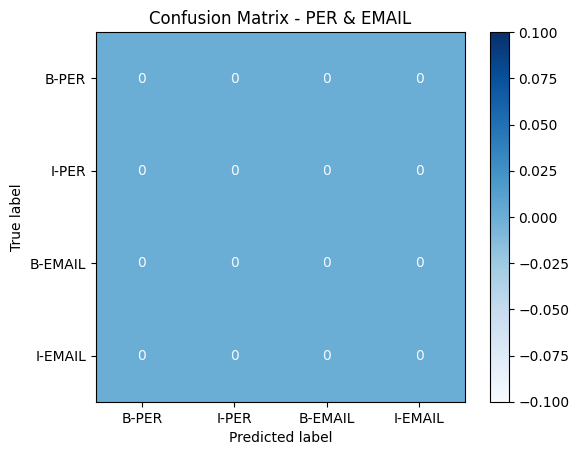

In [26]:
# 🔍 Evaluate Model
# 🔲 Confusion Matrix
labels_flat = results["eval_label_ids"].flatten()
preds_flat = np.argmax(results["eval_predictions"], axis=2).flatten()
mask = np.isin(labels_flat, [label_to_id["B-PER"], label_to_id["I-PER"], label_to_id["B-EMAIL"], label_to_id["I-EMAIL"]])
cm = confusion_matrix(labels_flat[mask], preds_flat[mask], labels=[label_to_id[l] for l in label_list if 'PER' in l or 'EMAIL' in l])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[l for l in label_list if 'PER' in l or 'EMAIL' in l])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - PER & EMAIL")
plt.show()

In [27]:
# 📊 Entity Stats
from collections import Counter
entity_counts = Counter()
for row in df_sig["signature"]:
    entities = re.findall(r'[\w\.-]+@[\w\.-]+|\b[A-Z][a-z]+\b', row)
    for ent in entities:
        if '@' in ent:
            entity_counts["Email"] += 1
        elif ent.istitle():
            entity_counts["Person/Org/Loc"] += 1

print("\nSignature entity stats:")
print(f"Signatures with detected entities: {len(df_sig)}")
print("Entities extracted:")
for k, v in entity_counts.items():
    print(f"{k}: {v} ({v/len(df_sig):.2%})")



Signature entity stats:
Signatures with detected entities: 95081
Entities extracted:
Person/Org/Loc: 2297523 (2416.38%)
Email: 160740 (169.06%)
